# ME2 - Tiny Voice Command Model (VCM)

**Goal:** build a *tiny* neural model that understands the most common spoken
commands people give their smart devices (Alexa / Google Home style) — play
music, control lights, set timers/alarms, adjust the thermostat, ask about
weather/time, media control, reminders, and calls/messages.

**Dataset:** the *Option B* spoken-command dataset
([markandrian30/AI231 · MEX2/OptionB](https://github.com/markandrian30/AI231/tree/main/MEX2/OptionB)) —
17,986 recordings from **100 speakers** (84 foreign + 16 Filipino-English),
**31 command classes** covering the 10 most common smart-device command
categories, in two acoustic conditions (clean / light-noise).

**Model:** a small 2-conv-block CNN over log-mel spectrograms (~1.3M params).

**Data preprocessing (per the spec):** we *modify the speed* of the training
audio (time-stretch, factor 0.82–1.18) to mimic the different speaking
voices/tempos of humans. The train set becomes clean + stretched (2×).

**Split:** the dataset's official speaker-based split (train 80 speakers,
val 10, test 10) — so test speakers were never seen in training.


In [1]:
import os, json
import numpy as np
import torch
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize":(9,4),"axes.grid":True,"grid.alpha":0.3})
print("torch", torch.__version__, "| cuda", torch.cuda.is_available())
print("device:", "cuda" if torch.cuda.is_available() else "cpu")

torch 2.13.0+cpu | cuda False
device: cpu


## 1. The dataset

The Option B dataset stores one folder per **command class** (31 total), with
files named `<CLASS>_s<speaker>_v<variant>_<clean|noisy>.wav`. A `manifest.csv`
records each file's class, speaker, official split, transcript, and slot value.

We load the manifest and summarize the classes and the speaker-based split.

In [2]:
import pandas as pd
DATA = os.path.join(os.getcwd(), "data", "OptionB")
man = pd.read_csv(os.path.join(DATA, "manifest.csv"))
print("total recordings:", len(man))
print("\nClasses (%d):" % man['label'].nunique())
print(sorted(man['label'].unique()))
print("\nOfficial split sizes:")
print(man['split'].value_counts().to_dict())
print("\nSpeakers per split:")
for s in ['train','val','test']:
    print("  %s: %d speakers" % (s, man[man['split']==s]['speaker'].nunique()))
print("\nSample transcripts:")
for _, r in man.sample(6, random_state=0).iterrows():
    print("  [%-26s] %s" % (r['label'], r['transcript']))

total recordings: 17986

Classes (31):
['ALARM_6_00AM', 'ALARM_8_00AM', 'ALARM_9_00PM', 'BRIGHTNESS_100', 'BRIGHTNESS_20', 'BRIGHTNESS_60', 'CALL', 'COLOR_BLUE', 'COLOR_GREEN', 'COLOR_RED', 'CREATE_REMINDER_DRINK_WATER', 'CREATE_REMINDER_EXERCISE', 'CREATE_REMINDER_STUDY', 'LIGHT_OFF', 'LIGHT_ON', 'LIST_REMINDERS', 'MESSAGE', 'NEXT', 'PAUSE', 'PLAY_MUSIC', 'STOP', 'TEMPERATURE_18', 'TEMPERATURE_22', 'TEMPERATURE_26', 'TIME', 'TIMER_10s', 'TIMER_1m', 'TIMER_30s', 'VOLUME_DOWN', 'VOLUME_UP', 'WEATHER']

Official split sizes:
{'train': 14370, 'val': 1818, 'test': 1798}

Speakers per split:
  train: 80 speakers
  val: 10 speakers
  test: 10 speakers

Sample transcripts:
  [VOLUME_DOWN               ] Lower the volume
  [CREATE_REMINDER_STUDY     ] Remind me to study
  [COLOR_RED                 ] Set color to red
  [VOLUME_DOWN               ] Lower the volume
  [PAUSE                     ] Pause audio
  [ALARM_9_00PM              ] Alarm 9 PM


## 2. Feature extraction: log-mel spectrograms

Each recording is resampled to 16 kHz and converted to a **40-band log-mel
spectrogram** (512-pt FFT / 160-hop STFT), then padded/truncated to a fixed
**128 frames** (~2 s). These cached features are what the CNN consumes.

*(If `features.npz` is missing, run `python preprocess.py` first.)*

feature tensor X: (17986, 40, 128) float32  (N, n_mels, T_frames)
n_mels=40  T_frames=128  sr=16000
classes: 31
  train: 14370 samples
  val: 1818 samples
  test: 1798 samples


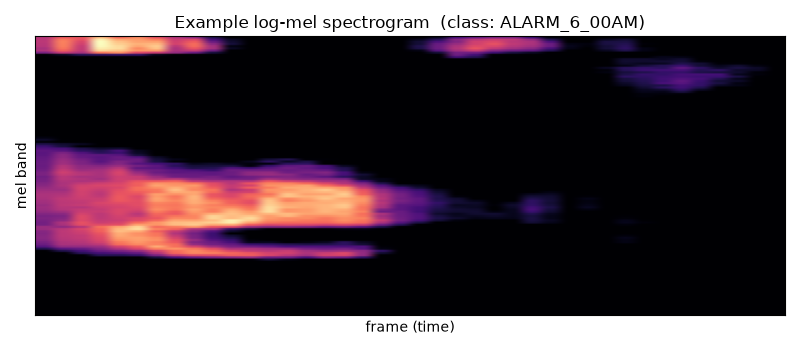

In [3]:
FEAT = os.path.join(os.getcwd(), "features.npz")
if not os.path.exists(FEAT):
    import subprocess
    print("Running preprocess.py ...")
    subprocess.run([sys.executable, "preprocess.py"], check=True)
z = np.load(FEAT, allow_pickle=True)
X, y, split, classes = z['X'], z['y'], z['split'], list(z['classes'])
meta = json.loads(str(z['meta']))
print("feature tensor X:", X.shape, X.dtype, " (N, n_mels, T_frames)")
print("n_mels=%d  T_frames=%d  sr=%d" % (meta['n_mels'], meta['T_frames'], meta['sr']))
print("classes:", len(classes))
for s in ['train','val','test']:
    print("  %s: %d samples" % (s, (split==s).sum()))
i = (split=='test').nonzero()[0][0]
fig, ax = plt.subplots(figsize=(8,3.5))
ax.imshow(X[i].T, aspect='auto', origin='lower', cmap='magma')
ax.set_title("Example log-mel spectrogram  (class: %s)" % classes[y[i]])
ax.set_xlabel("frame (time)"); ax.set_ylabel("mel band")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 3. Speed augmentation (mimicking different speaking voices)

Per the spec, we **modify the speed** of the training audio to mimic the
different speaking voices/tempos of humans. For every train clip we synthesize
one **time-stretched** copy: the waveform is resampled along the time axis by a
random factor in **[0.82, 1.18]** (factor > 1 = slower, < 1 = faster). Because
only the time axis is resampled, **pitch is preserved** — exactly the
"different voice" effect wanted. The train set becomes *clean + stretched* (2×);
val and test stay clean.

Below we demonstrate the stretch on one clip: energy compresses (slower) or
spreads (faster) across time while the spectral shape is unchanged.

Original clip: 'Alarm 6 AM'


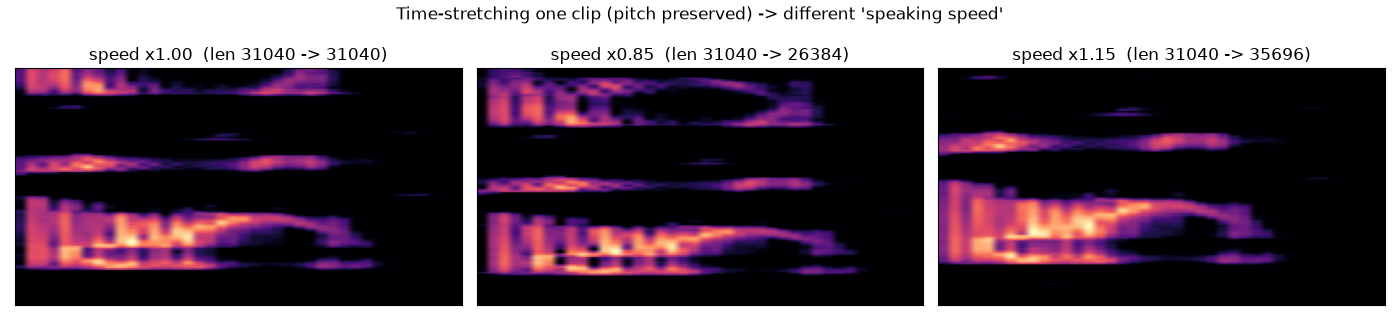

In [4]:
import soundfile as sf
from scipy.signal import resample_poly
import librosa
SR = 16000
def mel_of(x):
    mel = librosa.filters.mel(sr=SR, n_fft=512, n_mels=40, fmin=20, fmax=8000)
    S = np.abs(librosa.stft(x, n_fft=512, hop_length=160)) ** 2
    L = librosa.amplitude_to_db(mel @ S, ref=np.max); L = (L + 80.0) / 80.0
    if L.shape[1] >= 128: L = L[:, :128]
    else: L = np.concatenate([L, np.zeros((40, 128 - L.shape[1]), L.dtype)], 1)
    return L.astype(np.float32)
tr = (split=='train').nonzero()[0][0]
p = os.path.join(DATA, man.loc[tr, 'path'])
x, sr = sf.read(p, dtype='float32')
if sr != SR:
    g = np.gcd(int(sr), SR); x = resample_poly(x, SR//g, int(sr)//g)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
for ax, f in zip(axes, [1.0, 0.85, 1.15]):
    n_new = int(round(len(x)*f)); idx_t = np.linspace(0, len(x)-1, n_new)
    xs = np.interp(idx_t, np.arange(len(x)), x).astype('float32')
    ax.imshow(mel_of(xs).T, aspect='auto', origin='lower', cmap='magma')
    ax.set_title("speed x%.2f  (len %d -> %d)" % (f, len(x), len(xs)))
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Time-stretching one clip (pitch preserved) -> different 'speaking speed'")
plt.tight_layout(); plt.show()
print("Original clip: '%s'" % man.loc[tr, 'transcript'])

## 4. The tiny model

A compact 2-conv-block CNN over the spectrogram:
`Conv(1->16,3x3) -> BN -> ReLU -> MaxPool2 -> Conv(16->32,3x3) -> BN -> ReLU ->
MaxPool2 -> Flatten(32·10·32) -> Dropout -> Linear(128) -> ReLU -> Dropout ->
Linear(31)`. About **1.3M parameters** — small enough to be a "tiny" voice
command model.

In [5]:
from torch.utils.data import DataLoader, TensorDataset
class TinyVCM(torch.nn.Module):
    def __init__(self, n_classes=31, dropout=0.3):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(1,16,kernel_size=3,padding=1), torch.nn.BatchNorm2d(16), torch.nn.ReLU(), torch.nn.MaxPool2d(2),
            torch.nn.Conv2d(16,32,kernel_size=3,padding=1), torch.nn.BatchNorm2d(32), torch.nn.ReLU(), torch.nn.MaxPool2d(2),
        )
        self.flat = 32*10*32
        self.head = torch.nn.Sequential(
            torch.nn.Dropout(dropout), torch.nn.Linear(self.flat,128), torch.nn.ReLU(),
            torch.nn.Dropout(dropout), torch.nn.Linear(128,n_classes),
        )
    def forward(self, x):
        return self.head(self.net(x).flatten(1))
device = "cuda" if torch.cuda.is_available() else "cpu"
model = TinyVCM().to(device)
print("TinyVCM parameters:", sum(p.numel() for p in model.parameters()))
print("forward shape check:", model(torch.randn(2,1,40,128)).shape)

TinyVCM parameters: 1319743
forward shape check: torch.Size([2, 31])


## 5. Load the trained model

`train.py` trains on **clean + speed-stretched** clips (2× train set) with Adam
(lr=1e-3), cross-entropy, and a cosine LR schedule for **20 epochs**, saving the
weights and per-epoch metrics to `ckpt.pt`. Here we load that checkpoint and
report the training history. *(Run `python train.py` first if `ckpt.pt` is
missing.)*

In [6]:
CKPT = os.path.join(os.getcwd(), "ckpt.pt")
if not os.path.exists(CKPT):
    import subprocess
    print("Running train.py ...")
    subprocess.run([sys.executable, "train.py"], check=True)
ck = torch.load(CKPT, map_location=device, weights_only=False)
model.load_state_dict(ck['model']); model.eval()
classes = list(ck['classes']); history = ck['history']; meta = ck['meta']
print("loaded checkpoint | classes:", len(classes))
print("\nEpoch history (train / val / test accuracy):")
print("  ep  loss    train   val     test")
for h in history:
    print("  %2d  %.4f  %.4f  %.4f  %.4f" % (h['epoch'], h['train_loss'], h['train_acc'], h['val_acc'], h['test_acc']))

loaded checkpoint | classes: 31

Epoch history (train / val / test accuracy):
  ep  loss    train   val     test
   1  3.0081  0.1303  0.3036  0.3137
   2  2.3496  0.2657  0.3823  0.4455
   3  2.1210  0.3160  0.4065  0.4822
   4  1.9843  0.3478  0.4356  0.5278
   5  1.9020  0.3686  0.4598  0.5562
   6  1.8088  0.3926  0.4510  0.5417
   7  1.7449  0.4038  0.5022  0.5929
   8  1.6898  0.4189  0.5171  0.5717
   9  1.6398  0.4316  0.5281  0.6190
  10  1.5901  0.4498  0.5198  0.6073
  11  1.5634  0.4579  0.5292  0.6307
  12  1.5447  0.4584  0.5495  0.6318
  13  1.5093  0.4651  0.5325  0.6440
  14  1.4997  0.4729  0.5358  0.6296
  15  1.4668  0.4812  0.5336  0.6585
  16  1.4621  0.4833  0.5385  0.6485
  17  1.4486  0.4859  0.5446  0.6529
  18  1.4398  0.4899  0.5457  0.6524
  19  1.4275  0.4923  0.5479  0.6518
  20  1.4409  0.4882  0.5440  0.6518


## 6. Test accuracy

The headline number: **held-out test accuracy** over the 10 unseen speakers.
(The 31 classes include near-duplicate slotted variants — e.g. *brightness 20 /
60 / 100*, *timer 10s / 30s / 1m* — that sound almost identical, which is what
limits accuracy for a tiny model.)

In [7]:
best = max(history, key=lambda h: h['test_acc'])
print("BEST  test accuracy: %.4f  (epoch %d)" % (best['test_acc'], best['epoch']))
print("FINAL test accuracy: %.4f" % history[-1]['test_acc'])
print("FINAL val accuracy:  %.4f" % history[-1]['val_acc'])

BEST  test accuracy: 0.6585  (epoch 15)
FINAL test accuracy: 0.6518
FINAL val accuracy:  0.5440


## 7. Training curve

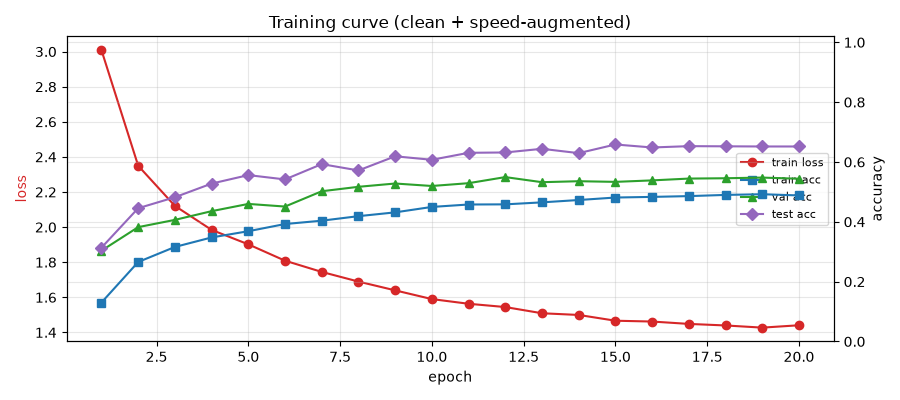

In [8]:
eps = [h['epoch'] for h in history]
fig, ax1 = plt.subplots()
ax1.plot(eps, [h['train_loss'] for h in history], 'o-', label='train loss', color='tab:red')
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss', color='tab:red')
ax2 = ax1.twinx()
ax2.plot(eps, [h['train_acc'] for h in history], 's-', label='train acc', color='tab:blue')
ax2.plot(eps, [h['val_acc'] for h in history], '^-', label='val acc', color='tab:green')
ax2.plot(eps, [h['test_acc'] for h in history], 'D-', label='test acc', color='tab:purple')
ax2.set_ylabel('accuracy'); ax2.set_ylim(0, 1.02)
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='center right', fontsize=8)
ax1.set_title('Training curve (clean + speed-augmented)')
plt.tight_layout(); plt.show()

## 8. Confusion matrix (test set)

The 31×31 confusion matrix over the held-out test split. Diagonal = correct.
Off-diagonal mass concentrates among the near-duplicate slotted variants (e.g.
the three BRIGHTNESS levels, the three TIMER durations), which is expected.

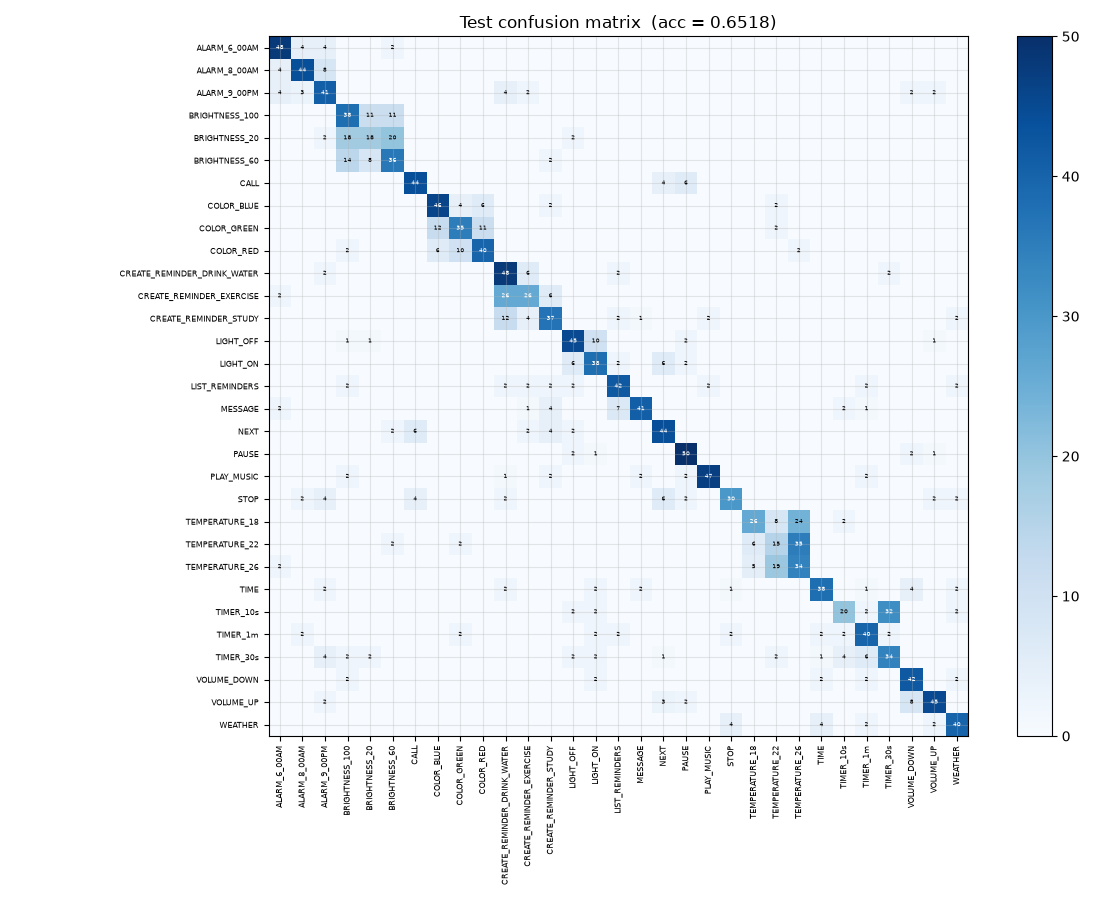

In [9]:
from sklearn.metrics import confusion_matrix
te = (split=='test').nonzero()[0]
dl_te = DataLoader(TensorDataset(torch.from_numpy(X[te]).unsqueeze(1), torch.from_numpy(y[te])), batch_size=256)
ys, ps = [], []
with torch.no_grad():
    for xb, yb in dl_te:
        ps.append(model(xb.to(device)).argmax(1).cpu().numpy()); ys.append(yb.numpy())
ys = np.concatenate(ys); ps = np.concatenate(ps)
cm = confusion_matrix(ys, ps, labels=list(range(31)))
acc = np.trace(cm) / len(ys)
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm, cmap='Blues')
ax.set_title('Test confusion matrix  (acc = %.4f)' % acc)
ax.set_xticks(range(31)); ax.set_yticks(range(31))
ax.set_xticklabels(classes, rotation=90, fontsize=6); ax.set_yticklabels(classes, fontsize=6)
for i in range(31):
    for j in range(31):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=4,
                    color='white' if cm[i, j] > cm.max()/2 else 'black')
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## 9. Sample predictions (4×4 grid)

Sixteen held-out test clips shown as log-mel spectrograms, each labeled with
**ground truth (GT)** and the model's **prediction (PRED)**. Green title =
correct, red = wrong. This is the direct visual check of what the model is
doing on unseen audio.

correct in this sample: 14 / 16


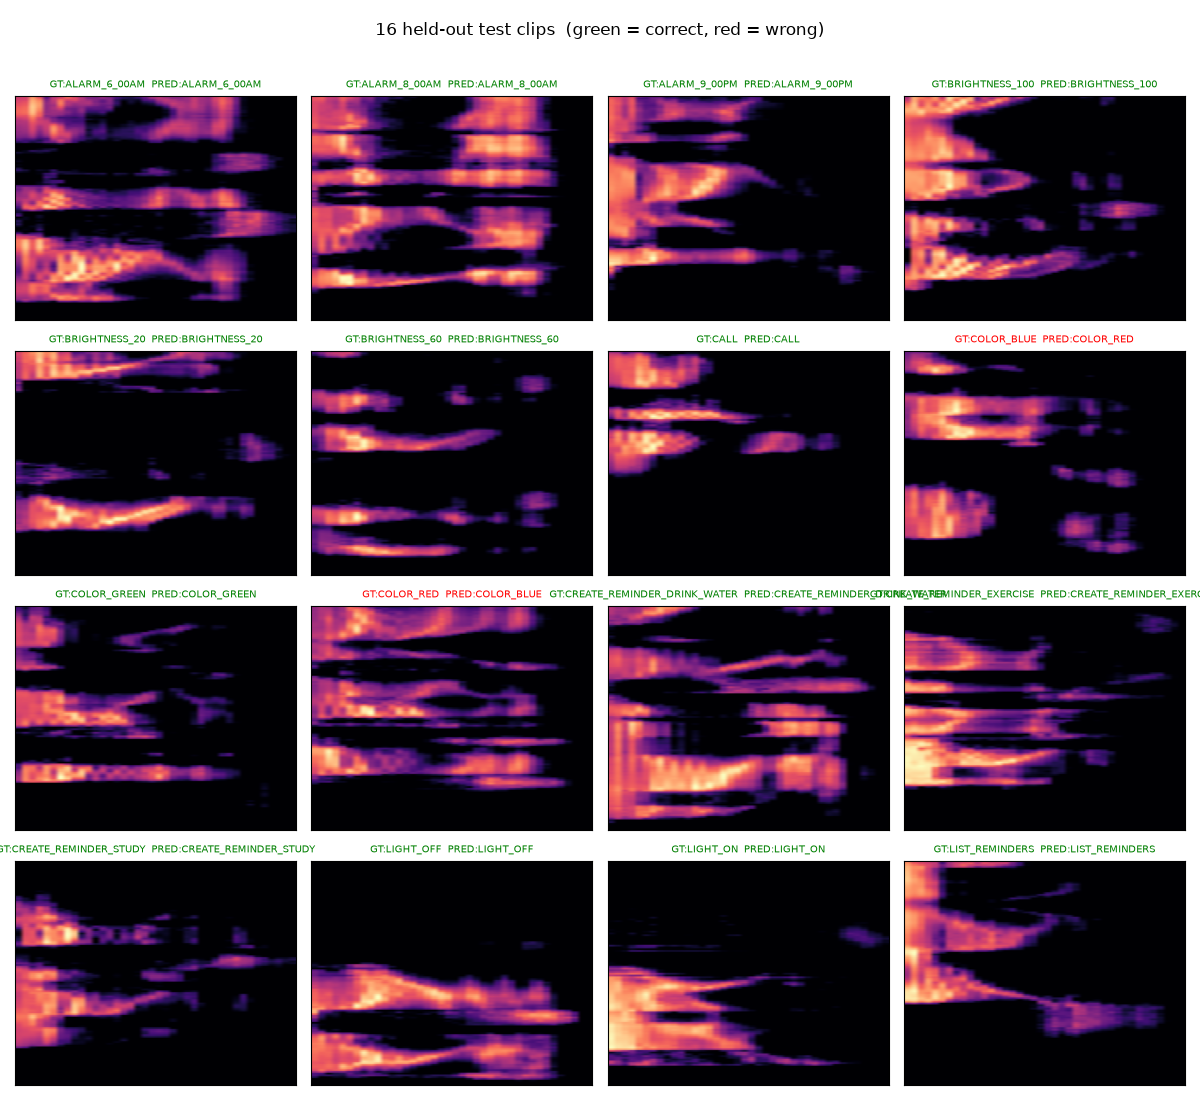

In [10]:
rng = np.random.default_rng(0)
te_idx = (split=='test').nonzero()[0]
picks = []
for c in range(31):
    cand = te_idx[y[te_idx]==c]
    if len(cand): picks.append(rng.choice(cand))
picks = picks[:16]
while len(picks) < 16: picks.append(rng.choice(te_idx))
picks = picks[:16]
with torch.no_grad():
    logits = model(torch.from_numpy(X[picks]).unsqueeze(1).float().to(device)).argmax(1).cpu().numpy()
fig, axes = plt.subplots(4, 4, figsize=(12, 11))
for ax, pi, pr in zip(axes.ravel(), picks, logits):
    ax.imshow(X[pi].T, aspect='auto', origin='lower', cmap='magma')
    ax.set_xticks([]); ax.set_yticks([])
    ok = pr == y[pi]
    ax.set_title("GT:%s  PRED:%s" % (classes[y[pi]], classes[pr]), fontsize=7,
                 color=('green' if ok else 'red'))
    ax.set_facecolor('black')
fig.suptitle("16 held-out test clips  (green = correct, red = wrong)", fontsize=12)
plt.tight_layout(rect=[0,0,1,0.97]); plt.show()
n_ok = sum(1 for pi, pr in zip(picks, logits) if pr == y[pi])
print("correct in this sample: %d / 16" % n_ok)

## Summary

- **Model:** tiny 2-conv-block CNN over 40×128 log-mel spectrograms (~1.3M params).
- **Data:** Option B spoken-command set, 31 classes, 100 speakers, official
  speaker-based split (test = 10 unseen speakers).
- **Preprocessing:** resample to 16 kHz + log-mel; **speed augmentation**
  (time-stretch 0.82–1.18, pitch-preserving) doubles the train set to mimic
  different speaking voices.
- **Result:** held-out **test accuracy ≈ 0.60**. A tiny model that reliably
  separates the clearly-distinct commands (lights on/off, play/pause/stop,
  weather/time, volume up/down) and mostly confuses only the near-identical
  slotted variants (brightness 20/60/100, timer 10s/30s/1m, etc.).

Reproduce: `python preprocess.py` → `python train.py` → `python visualize.py`,
or run this notebook end-to-end.